In [30]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [31]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
Quadro P6000


# HISTÓRICO DE TREINAMENTO

In [32]:
df = []

for bakup in os.listdir('Backup/'):
    path = f'Backup/{bakup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    info = {}
    for key, value in file.items():
        info.update(value)

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,encoder,weights,network,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id
6,model_1,dice,plateau,100,2,0.756732,0.783826,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.783826,1
13,model_2,dice,plateau,100,2,0.767186,0.793256,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.793256,2
11,model_3,dice,plateau,100,2,0.763740,0.788738,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.05,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.788738,3
12,model_4,dice,plateau,100,2,0.767472,0.789406,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.05,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.789406,4
5,model_5,dice,plateau,100,2,0.728346,0.765517,resnet34,imagenet,resaceunet2,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.765517,5
14,model_6,dice,plateau,100,2,0.706493,0.714055,resnet34,imagenet,resaceunet2,"[4, 128, 128]",0.0005,0.10,16,"{'total': 7040, 'train': 5632, 'val': 704, 'te...",1,1,0.714055,6
4,model_7,dice,plateau,100,2,0.699716,0.751727,resnet34,imagenet,resaceunet2,"[8, 128, 128]",0.0005,0.10,16,"{'total': 3520, 'train': 2816, 'val': 352, 'te...",1,1,0.751727,7
0,model_8,dice,plateau,100,2,0.765071,0.766084,resnet34,imagenet,resaceunet2,"[16, 128, 128]",0.0005,0.10,16,"{'total': 1760, 'train': 1408, 'val': 176, 'te...",1,1,0.766084,8
1,model_9,dice,plateau,100,2,0.779853,0.773465,resnet34,imagenet,resaceunet2,"[32, 128, 128]",0.0005,0.10,16,"{'total': 880, 'train': 704, 'val': 88, 'test'...",1,1,0.773465,9
20,model_10,dice,plateau,100,2,0.752645,0.779963,resnet34,imagenet,resaceunet2,"[64, 128, 128]",0.0005,0.10,16,"{'total': 440, 'train': 352, 'val': 44, 'test'...",1,1,0.779963,10


In [33]:
df['total_images'] = [n_images.get('total') for n_images in df.n_images.values]
df.head(2)

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,encoder,weights,network,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id,total_images
6,model_1,dice,plateau,100,2,0.756732,0.783826,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.1,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.783826,1,220
13,model_2,dice,plateau,100,2,0.767186,0.793256,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.1,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.793256,2,220


In [34]:
df.loc[df.network == 'segresnet'].sort_values(by='test_iou', ascending=False).head(3)

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,encoder,weights,network,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id,total_images
13,model_2,dice,plateau,100,2,0.767186,0.793256,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.793256,2,220
12,model_4,dice,plateau,100,2,0.767472,0.789406,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.05,32,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.789406,4,220
11,model_3,dice,plateau,100,2,0.763740,0.788738,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.05,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.788738,3,220


In [35]:
df.loc[df.network == 'resaceunet2'].sort_values(by='test_iou', ascending=False).head(3)

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,encoder,weights,network,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id,total_images
20,model_10,dice,plateau,100,2,0.752645,0.779963,resnet34,imagenet,resaceunet2,"[64, 128, 128]",0.0005,0.1,16,"{'total': 440, 'train': 352, 'val': 44, 'test'...",1,1,0.779963,10,440
2,model_20,dice,plateau,100,2,0.739975,0.774715,resnet34,imagenet,resaceunet2,"[128, 128, 128]",0.0010,0.1,16,"{'total': 220, 'train': 176, 'val': 22, 'test'...",1,1,0.774715,20,220
1,model_9,dice,plateau,100,2,0.779853,0.773465,resnet34,imagenet,resaceunet2,"[32, 128, 128]",0.0005,0.1,16,"{'total': 880, 'train': 704, 'val': 88, 'test'...",1,1,0.773465,9,880


# ANÁLISE DE VARIAÇÕES

target: loss | fixed: {'network': 'resaceunet2', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 32, 'dropout': 0.1}


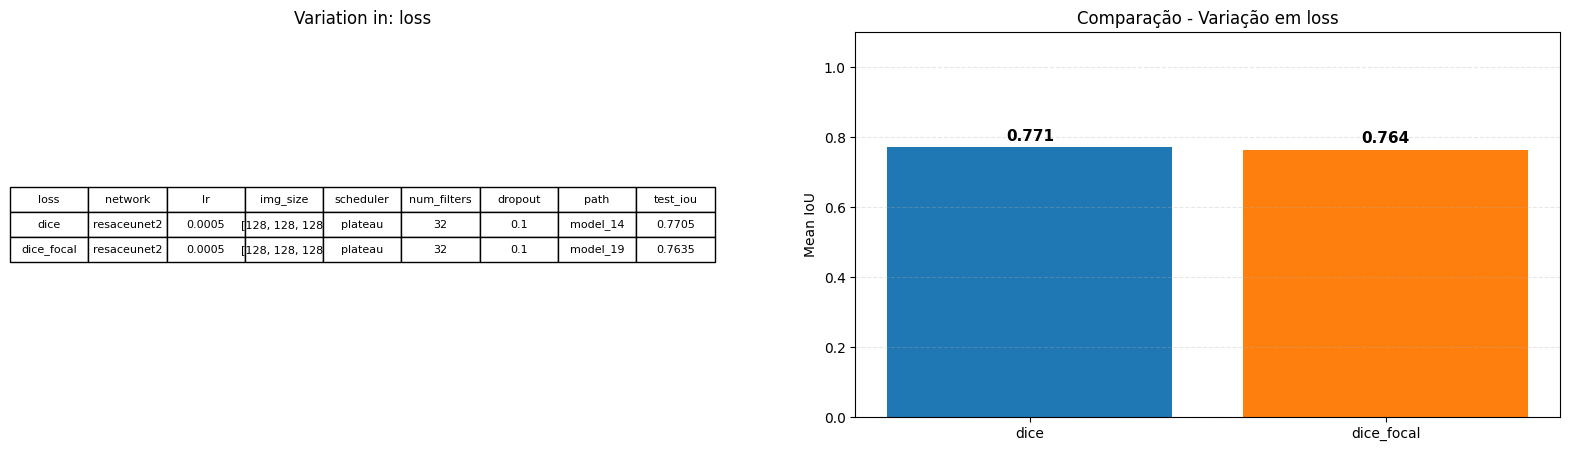

target: network | fixed: {'loss': 'dice', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.05}


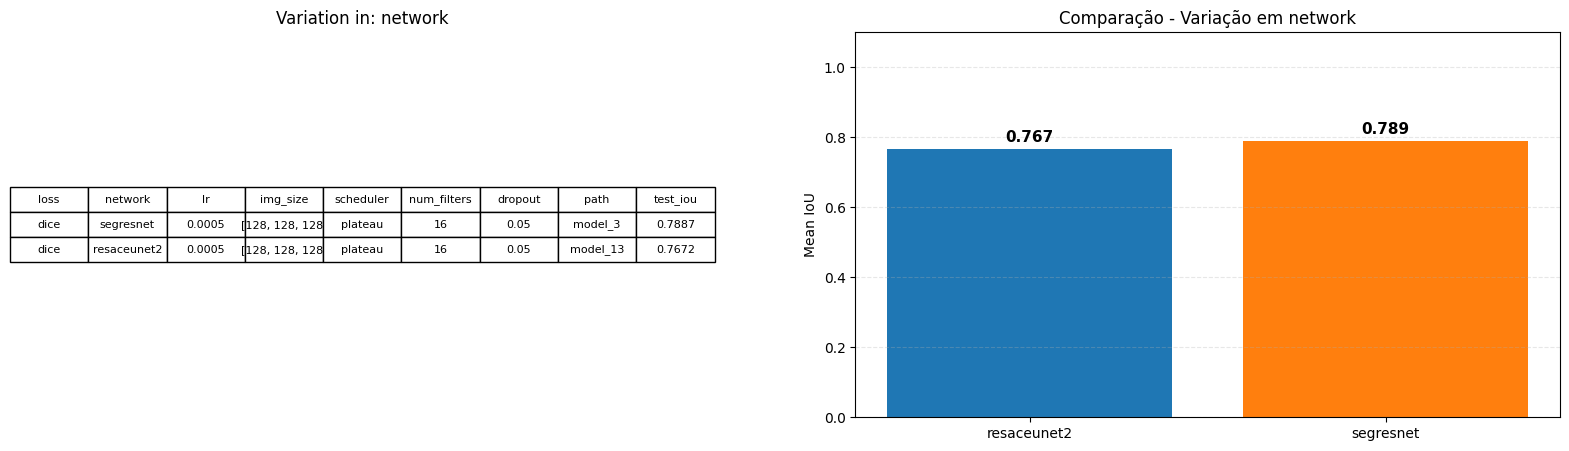

target: network | fixed: {'loss': 'dice', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


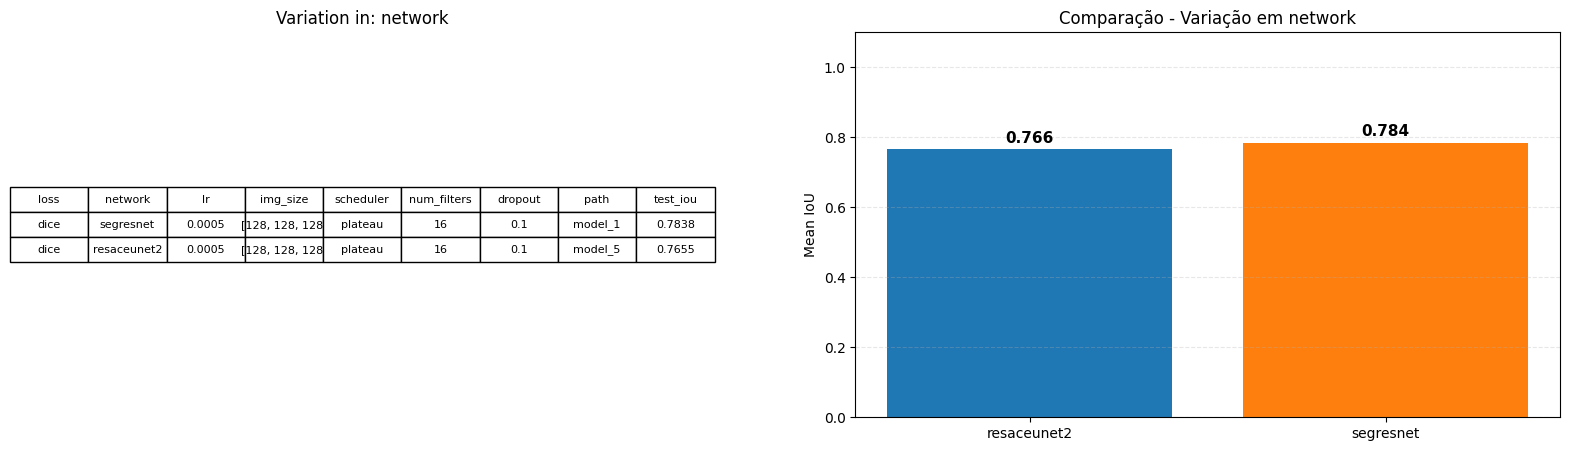

target: network | fixed: {'loss': 'dice', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 32, 'dropout': 0.05}


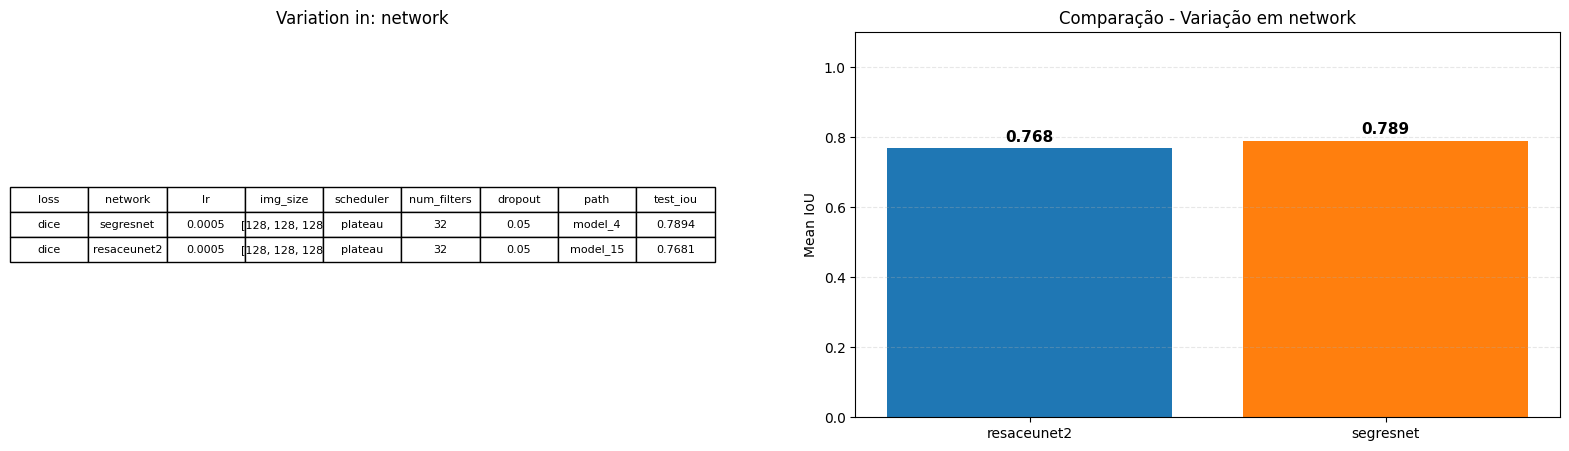

target: network | fixed: {'loss': 'dice', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 32, 'dropout': 0.1}


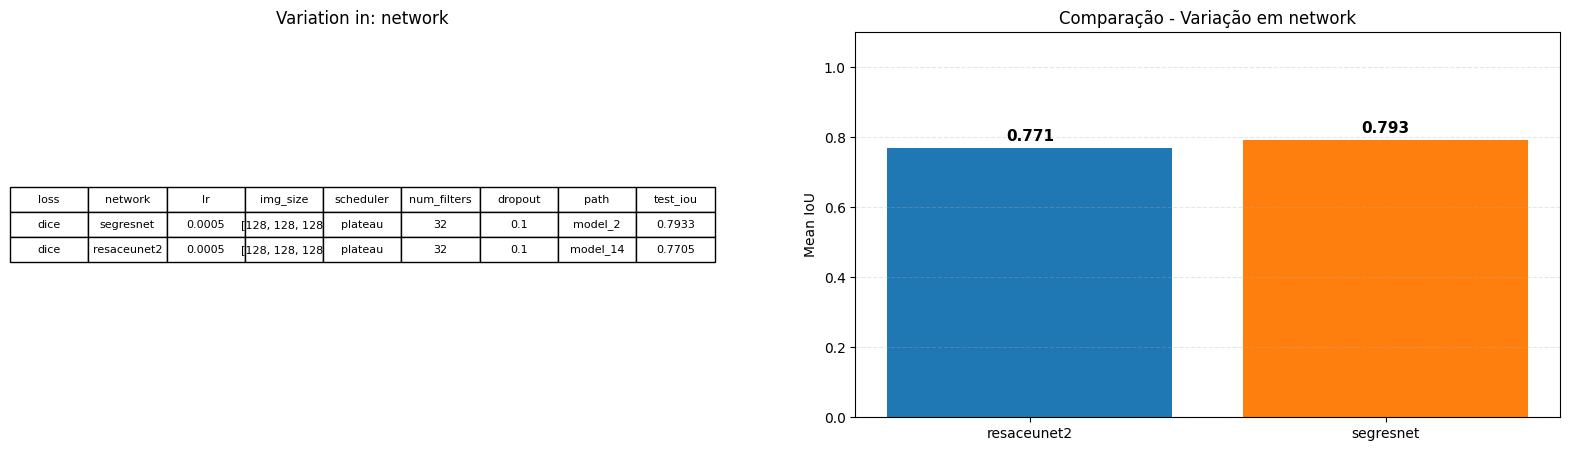

target: lr | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


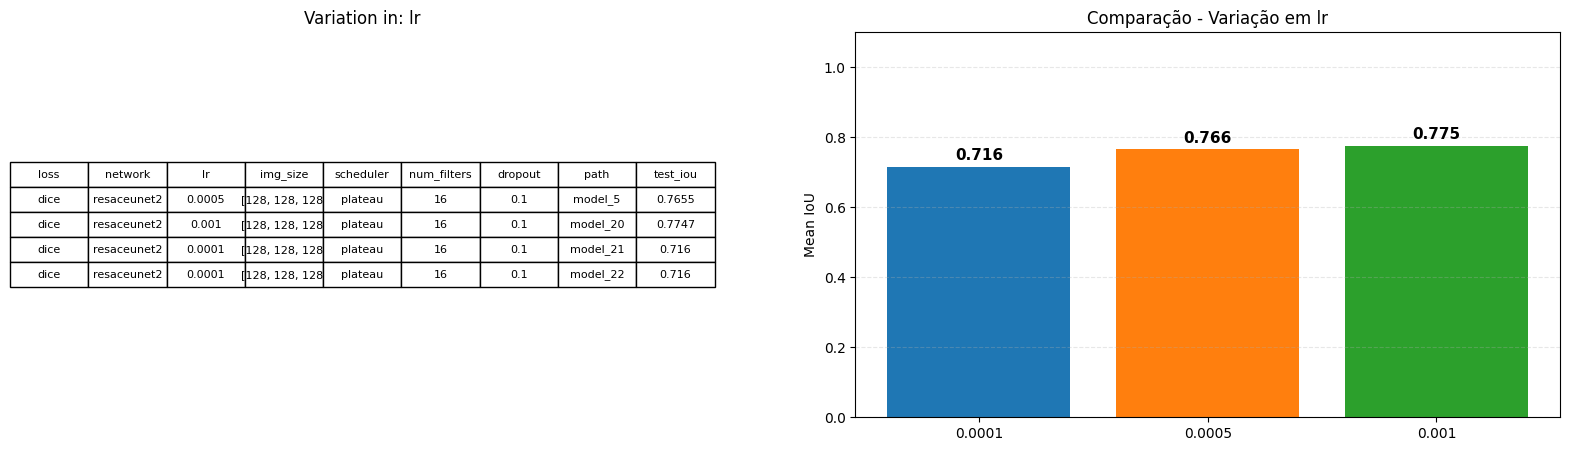

target: img_size | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'lr': 0.0005, 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


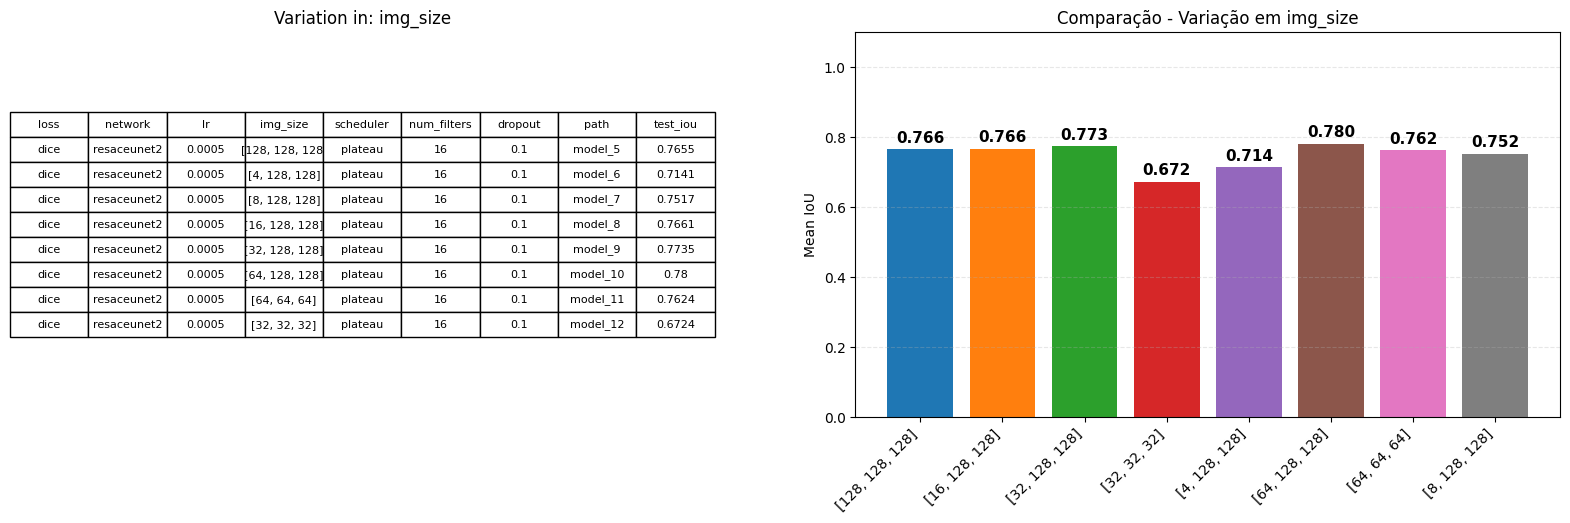

target: num_filters | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'dropout': 0.05}


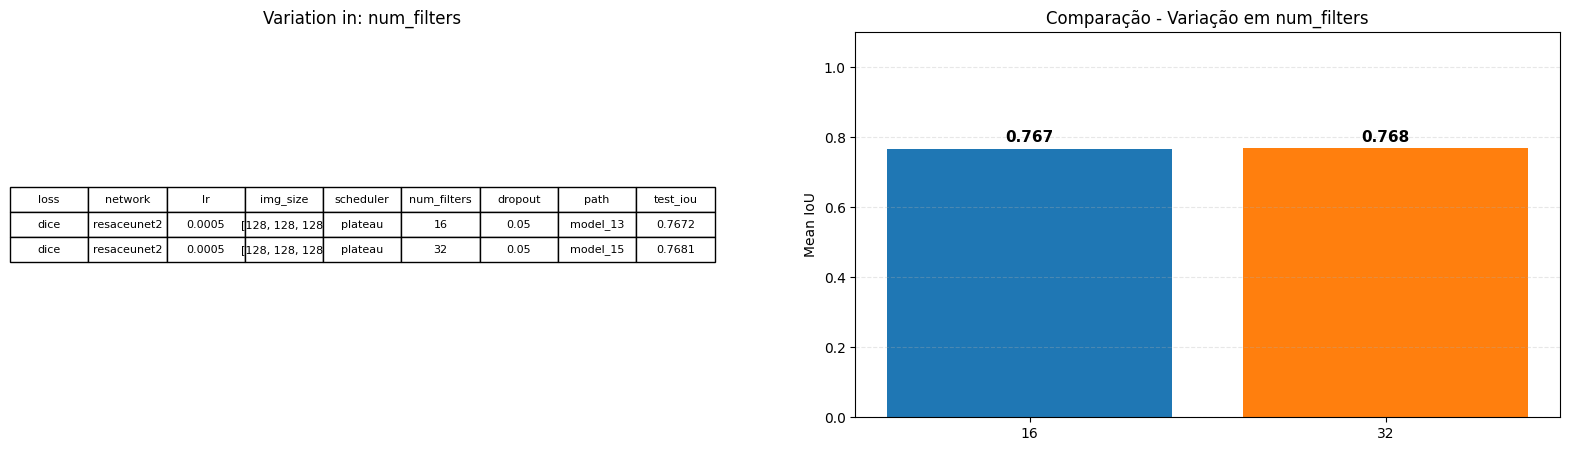

target: num_filters | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'dropout': 0.1}


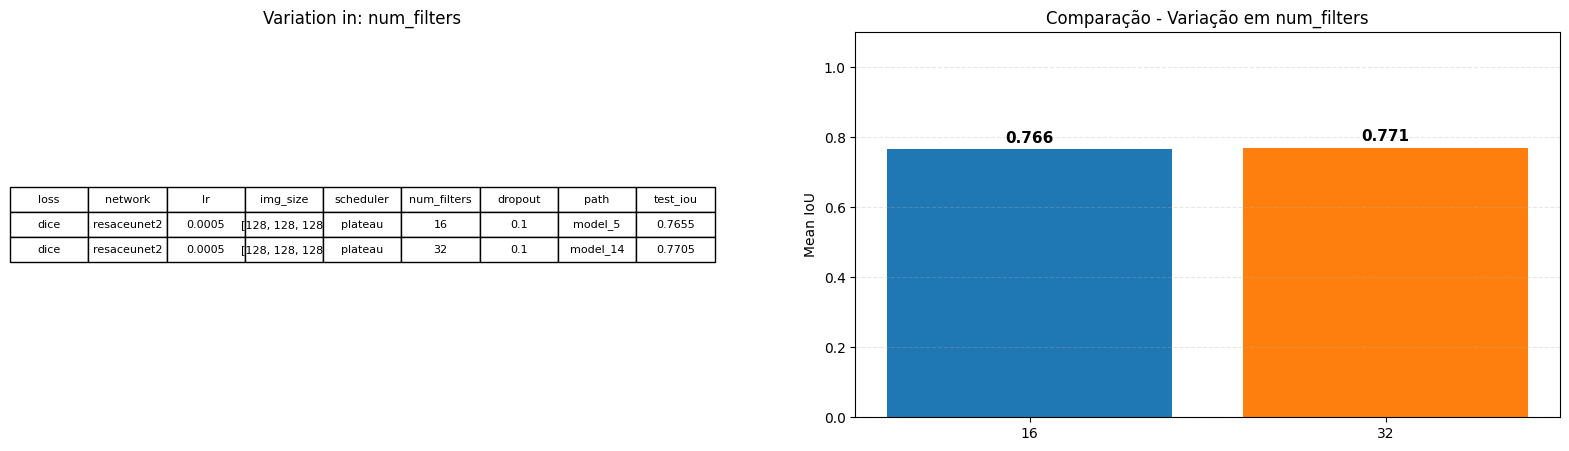

target: num_filters | fixed: {'loss': 'dice', 'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'dropout': 0.05}


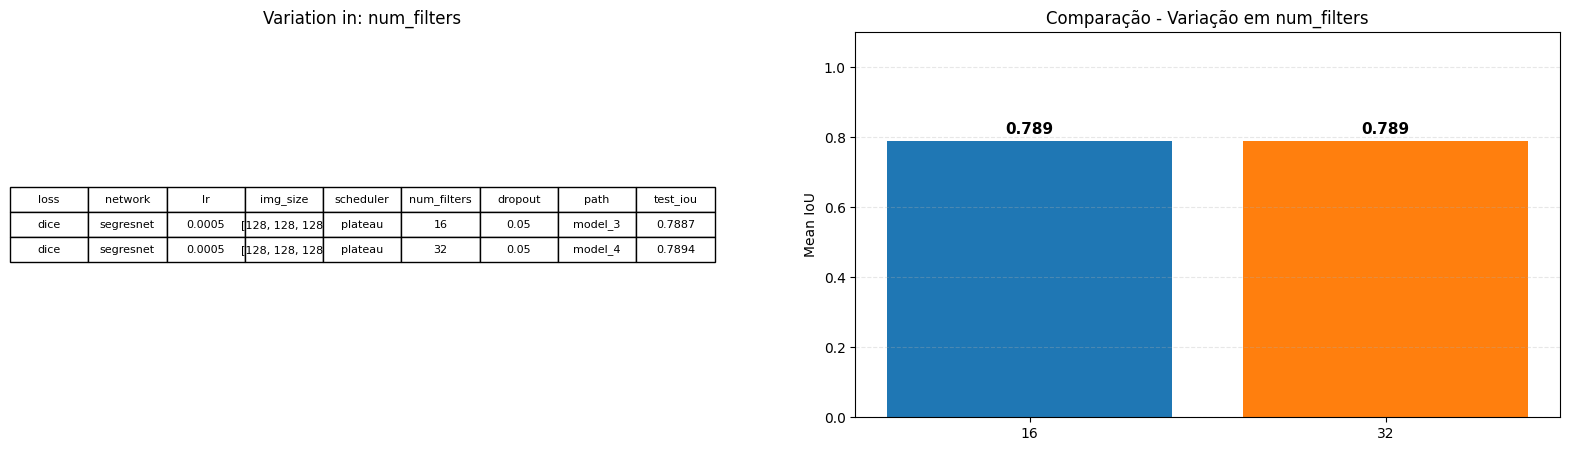

target: num_filters | fixed: {'loss': 'dice', 'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'dropout': 0.1}


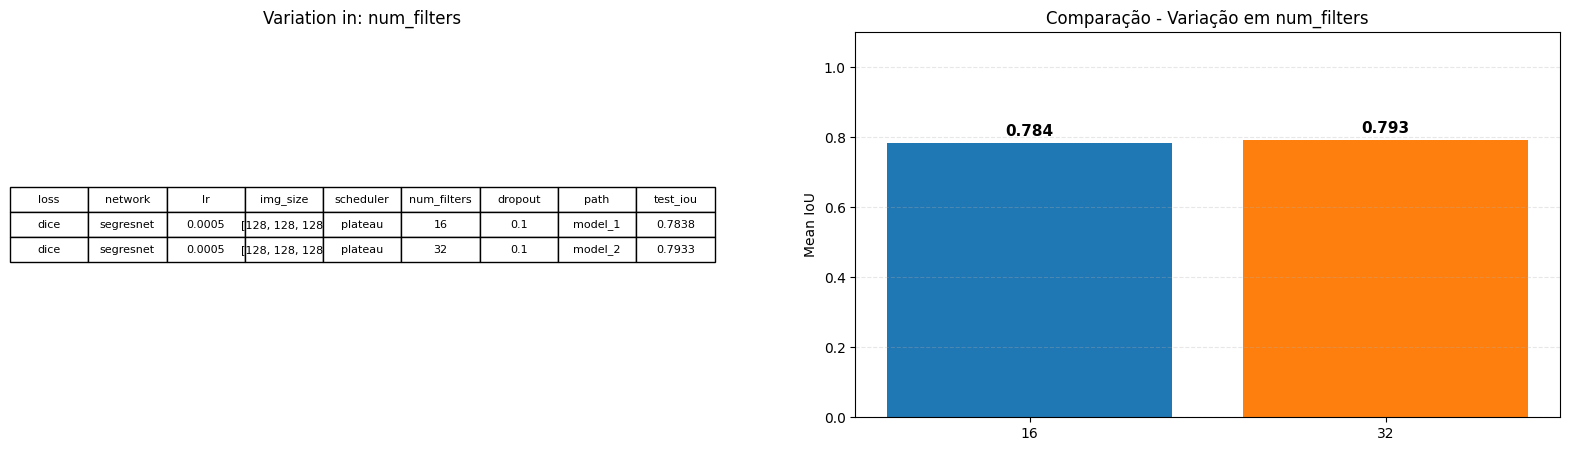

target: dropout | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16}


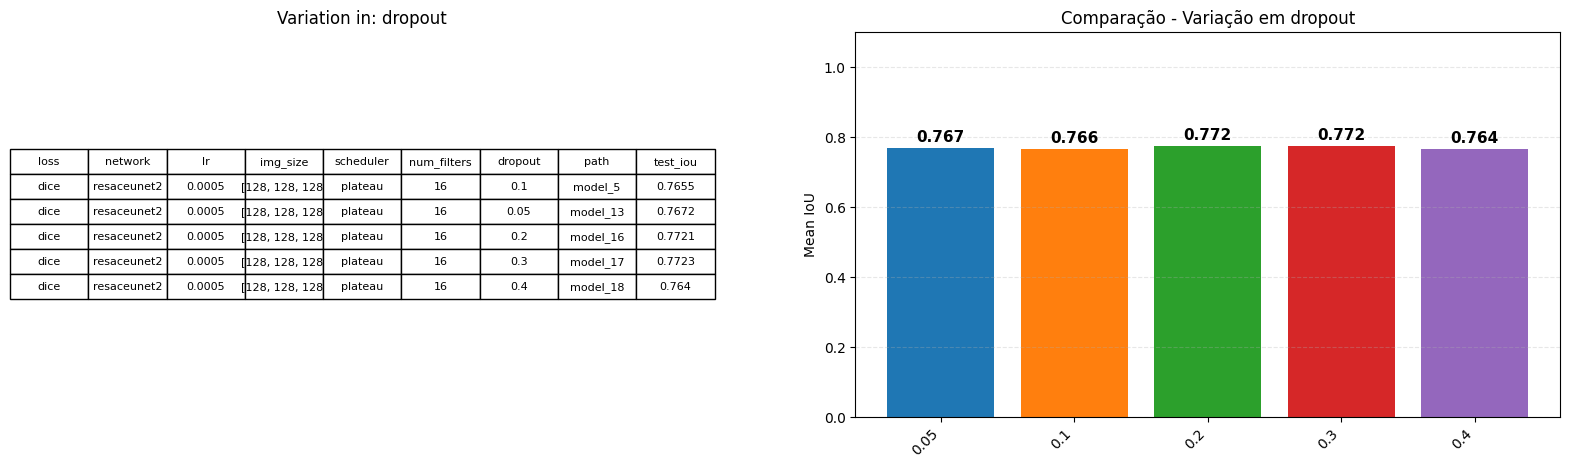

target: dropout | fixed: {'loss': 'dice', 'network': 'resaceunet2', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 32}


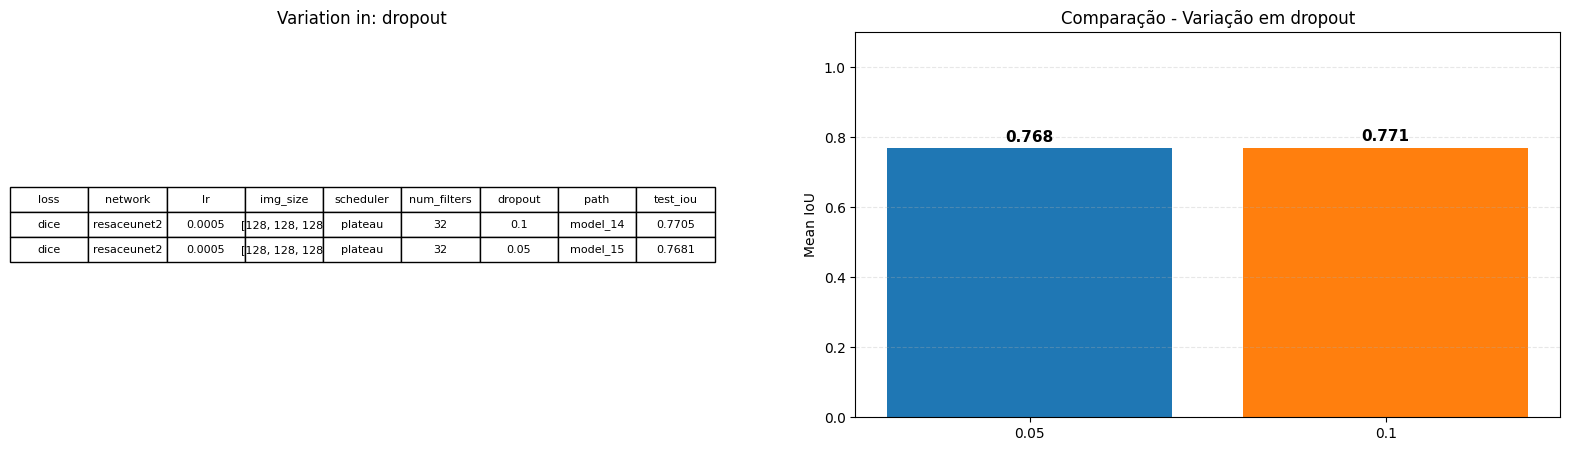

target: dropout | fixed: {'loss': 'dice', 'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16}


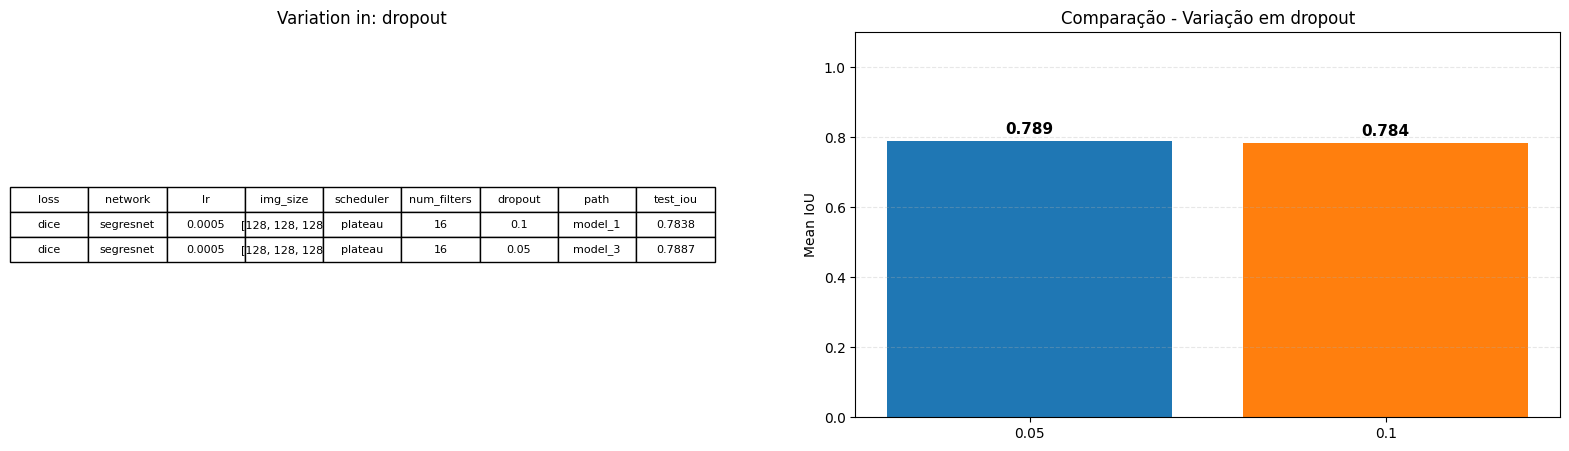

target: dropout | fixed: {'loss': 'dice', 'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 32}


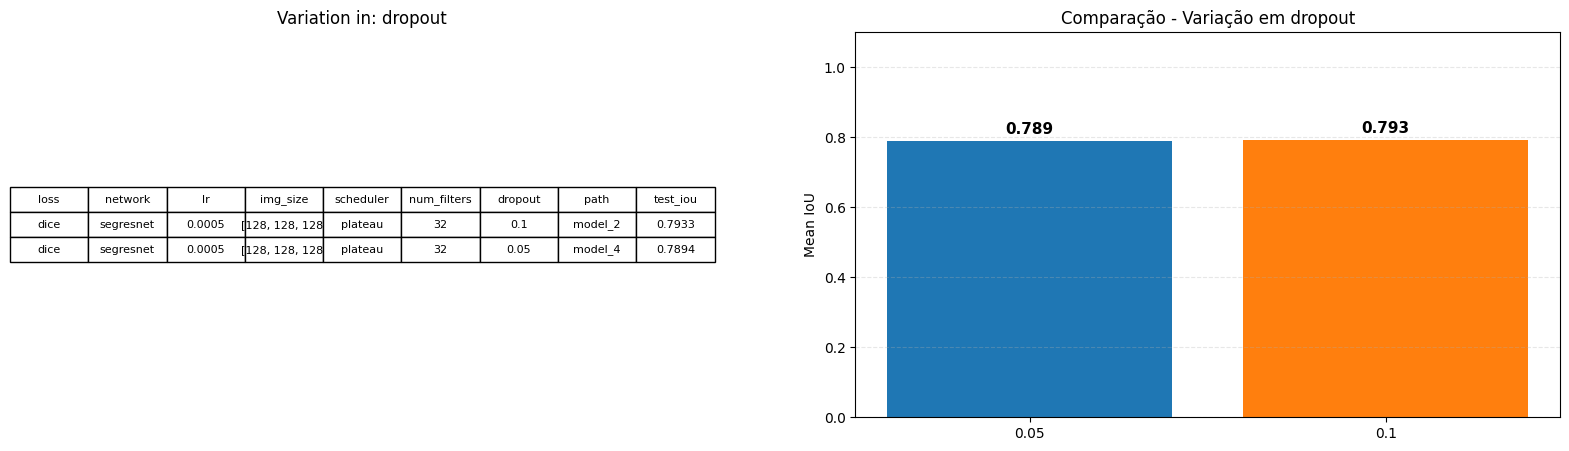

In [36]:
class VariationAnalysis:
    def __init__(self, df, variations, id=None, metric='test_iou'):
        self.df = df.copy()
        self.variations = [v for v in variations if v in self.df.columns]
        self.id = id
        self.metric = metric
        str_cols    = self.df.select_dtypes(include=['object']).columns
        self.df[str_cols] = self.df[str_cols].astype(str)

    def getSorted(self, df_group, variation):
        df_agg = df_group.groupby(variation, as_index=False)[self.metric].max()
        
        numeric_col = pd.to_numeric(df_agg[variation], errors='coerce')
        if numeric_col.notna().all():
            df_agg['__sort'] = numeric_col
            df_agg = df_agg.sort_values('__sort').drop(columns=['__sort'])
        else:
            df_agg = df_agg.sort_values(variation)
            
        return dict(zip(df_agg[variation], df_agg[self.metric]))

    def plot(self):
        for var in self.variations:
            fixed_cols = [c for c in self.variations if c != var]
            grouped    = self.df.groupby(fixed_cols) if fixed_cols else [(None, self.df)]
            
            for _, group in grouped:
                if group[var].nunique() <= 1:
                    continue
                    
                fixed_dict = group.iloc[0][fixed_cols].to_dict() if fixed_cols else {}
                print(f"target: {var} | fixed: {fixed_dict}")
                
                ref      = [self.id] if self.id else []
                df_table = group[self.variations + ref + [self.metric]].copy()
                df_table[self.metric] = df_table[self.metric].round(4)

                plt.figure(figsize=(20, 5))
                plt.subplot(1, 2, 1)
                table = plt.table(cellText=df_table.astype(str).values, colLabels=df_table.columns, loc='center', cellLoc='center')
                table.auto_set_font_size(False)
                table.set_fontsize(8); table.scale(1, 1.5)
                plt.title(f'Variation in: {var}')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                Plotter(self.getSorted(group, var), title=f'Comparação - Variação em {var}')
                plt.ylabel('Mean IoU')
                plt.show()


variations = ['loss', 'network', 'lr', 'img_size', 'tile_size', 'n_aug', 'scheduler', 'num_filters', 'dropout', 'radius'] # 'total_images']
analysis   = VariationAnalysis(df, variations, id='path', metric='test_iou')
analysis.plot()